In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from ion_simulbox import Ion
from ion_simulbox.laser import Laser, PulseLaser, Polarization
from ion_simulbox.experiment import Experiment
from ion_simulbox.units import Units, Constants
from ion_simulbox.utils import get_resonant_frequency

In [3]:
ion = Ion("Ba", 138)

In [23]:
ion.apply_magnetic_field(0)

In [24]:
ion.energy_levels

[FineStructure(energy=0.0 THz, n=6, I=0, L=0, J=0.5),
 FineStructure(energy=607.4263 THz, n=6, I=0, L=1, J=0.5),
 FineStructure(energy=658.1165 THz, n=6, I=0, L=1, J=1.5),
 FineStructure(energy=146.1144 THz, n=5, I=0, L=2, J=1.5),
 FineStructure(energy=170.1264 THz, n=5, I=0, L=2, J=2.5)]

In [25]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
    intensity=2550, 
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [26]:
laser_650 = Laser(
    name="650 nm",
    frequency=get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]),
    intensity=250, 
    line_width=10 * Units.kHz, 
    polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1 / np.sqrt(2), -1j / np.sqrt(2))
)

In [35]:
experiment = Experiment(ion, 0.e-5 * Units.T)

In [36]:
experiment.add_levels([
    experiment.total_level_name_map["6S0.5"],
    experiment.total_level_name_map["6P0.5"],
]) # , ion.energy_levels[3]])

In [37]:
experiment.add_laser(laser_493)
# experiment.add_laser(laser_650)

In [38]:
experiment.compile()

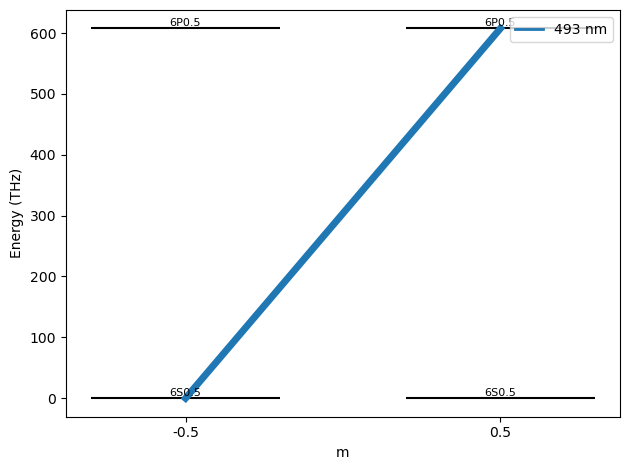

In [39]:
experiment.plot_transitions()

In [40]:
2 * np.pi * get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),

(3816572003354459.5,)

In [41]:
(P_state.energy - S_state.energy) / Constants.h_bar

3816572003354460.0

In [42]:
S_states = experiment.total_level_name_map["6S0.5"].zeeman_levels
P_states = experiment.total_level_name_map["6P0.5"].zeeman_levels
H_list = []
for S_state in S_states:
    for P_state in P_states:
        detunning = 2 * np.pi * laser_493.frequency - (P_state.energy - S_state.energy) / Constants.h_bar
        print(detunning)
        # H_list.append()

-0.5
-0.5
-0.5
-0.5
